<a href="https://colab.research.google.com/github/sadhaaa/sadhapaEDA/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
#PHASE 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Load the dataset
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bank_marketing_test.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())
print(df.info())

(8237, 21)
   age          job  marital    education  default housing loan    contact  \
0   56     services  married  high.school       no      no  yes  telephone   
1   41  blue-collar  married      unknown  unknown      no   no  telephone   
2   25     services   single  high.school       no     yes   no  telephone   
3   35  blue-collar  married     basic.6y       no     yes   no  telephone   
4   46  blue-collar  married     basic.6y  unknown     yes  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx 

In [42]:
# 2.Basic statistical analysis
print(df.describe())
print(df.describe(include="object"))
print(df.dtypes.value_counts())

               age     duration    campaign        pdays     previous  \
count  8237.000000  8237.000000  8237.00000  8237.000000  8237.000000   
mean     40.116547   256.007648     2.60471   962.228724     0.174335   
std      10.465328   259.728737     2.91562   187.533881     0.500565   
min      17.000000     4.000000     1.00000     0.000000     0.000000   
25%      32.000000   101.000000     1.00000   999.000000     0.000000   
50%      38.000000   179.000000     2.00000   999.000000     0.000000   
75%      47.000000   316.000000     3.00000   999.000000     0.000000   
max      89.000000  4918.000000    43.00000   999.000000     6.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx    euribor3m  nr.employed  
count   8237.000000     8237.000000    8237.000000  8237.000000  8237.000000  
mean       0.070147       93.577806     -40.545320     3.608206  5166.589790  
std        1.574685        0.582138       4.623626     1.735931    72.470977  
min       -3.400000       

In [43]:
# 3. Handling missing data
df = df.replace(["unknown", "nonexistent"], np.nan)
print(df.isnull().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())

age                  0
job                 60
marital             16
education          328
default           1757
housing            200
loan               200
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome          7113
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [44]:
# 4. Data cleaning
print(df.duplicated().sum())
df = df.drop_duplicates()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()
    df = df.reset_index(drop=True)

2


In [45]:
# 5. Data transformation
df.columns = df.columns.str.replace(".", "_", regex=False)
df["y_flag"] = df["y"].map({"yes": 1, "no": 0})
bins = [17, 30, 40, 50, 60, 100]
labels = ["18-30", "31-40", "41-50", "51-60", "60+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
print(df.head())

   age          job  marital          education default housing loan  \
0   56     services  married        high.school      no      no  yes   
1   41  blue-collar  married  university.degree      no      no   no   
2   25     services   single        high.school      no     yes   no   
3   35  blue-collar  married           basic.6y      no     yes   no   
4   46  blue-collar  married           basic.6y      no     yes  yes   

     contact month day_of_week  ...  previous  poutcome  emp_var_rate  \
0  telephone   may         mon  ...         0   failure           1.1   
1  telephone   may         mon  ...         0   failure           1.1   
2  telephone   may         mon  ...         0   failure           1.1   
3  telephone   may         mon  ...         0   failure           1.1   
4  telephone   may         mon  ...         0   failure           1.1   

   cons_price_idx cons_conf_idx  euribor3m  nr_employed   y  y_flag  age_group  
0          93.994         -36.4      4.857     

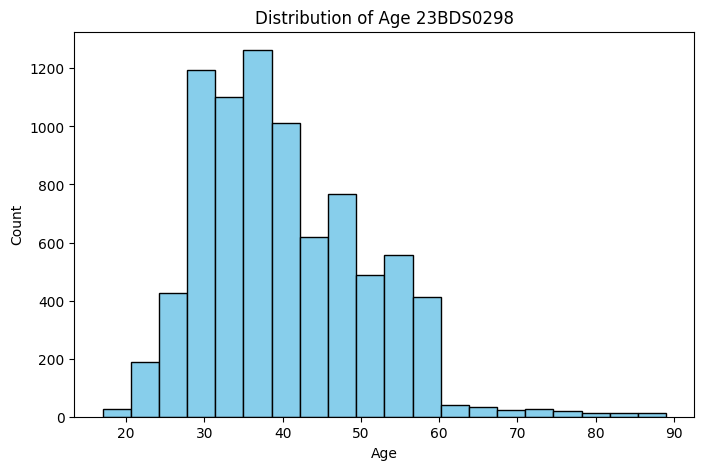

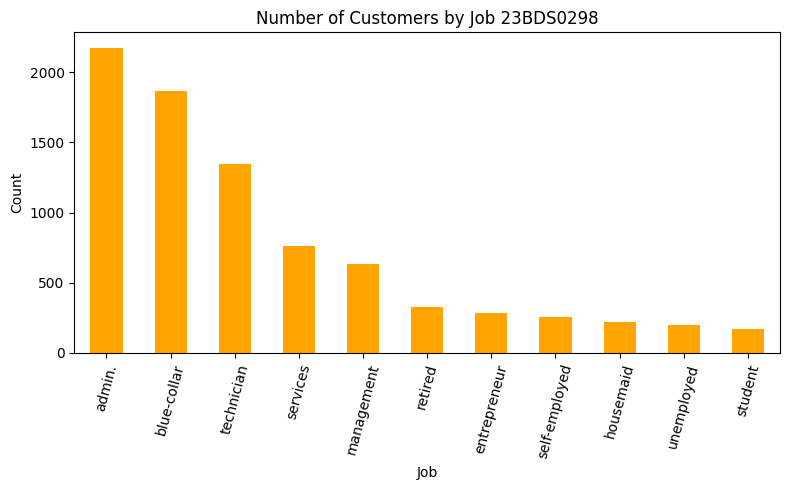

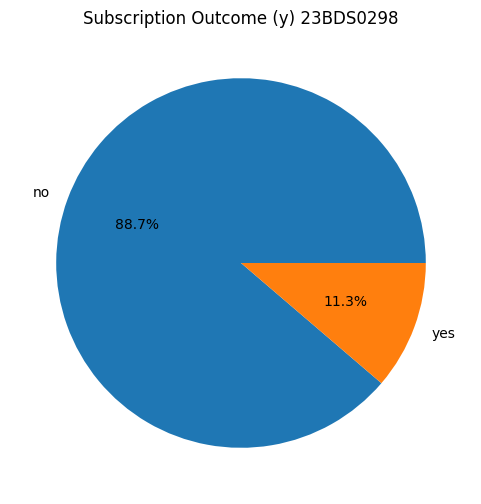

In [46]:
# 6. Univariate analysis
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Age 23BDS0298")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
df["job"].value_counts().plot(kind="bar", color="orange")
print("\n")
plt.title("Number of Customers by Job 23BDS0298")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
df["y"].value_counts().plot(kind="pie", autopct="%1.1f%%")
print("\n")
plt.title("Subscription Outcome (y) 23BDS0298")
plt.ylabel("")
plt.show()

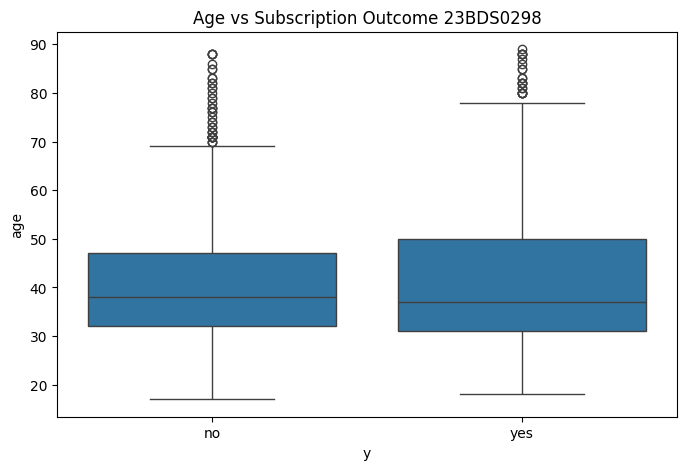

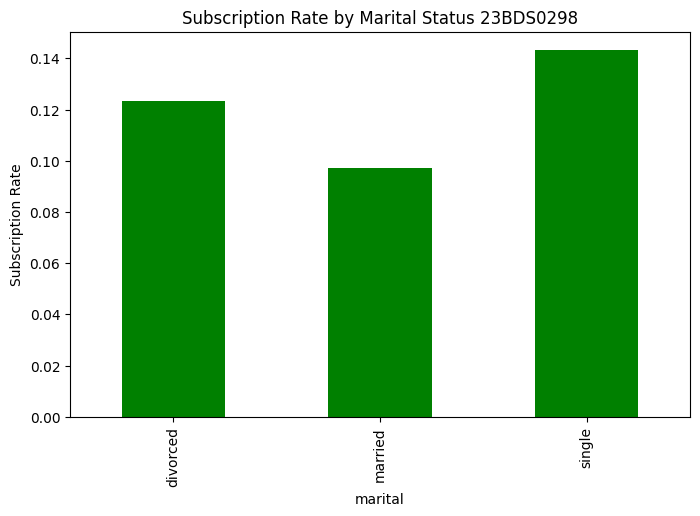

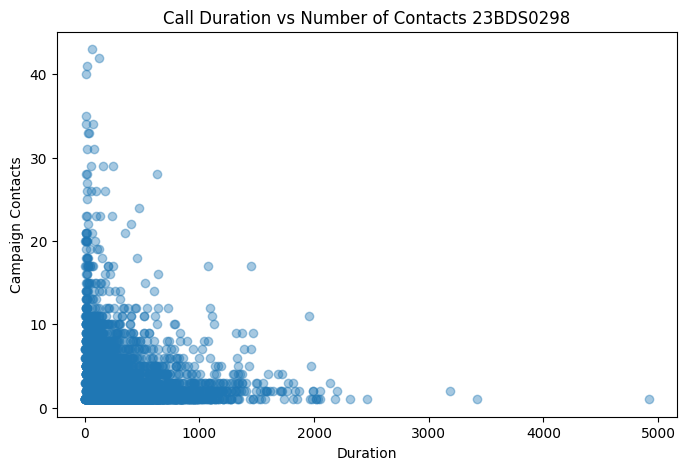

In [47]:
# 7. Bivariate analysis
plt.figure(figsize=(8, 5))
sns.boxplot(x="y", y="age", data=df)
plt.title("Age vs Subscription Outcome 23BDS0298")
plt.show()

plt.figure(figsize=(8, 5))
df.groupby("marital")["y_flag"].mean().plot(kind="bar", color="green")
print("\n")
plt.title("Subscription Rate by Marital Status 23BDS0298")
plt.ylabel("Subscription Rate")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["duration"], df["campaign"], alpha=0.4)
print("\n")
plt.title("Call Duration vs Number of Contacts 23BDS0298")
plt.xlabel("Duration")
plt.ylabel("Campaign Contacts")
plt.show()

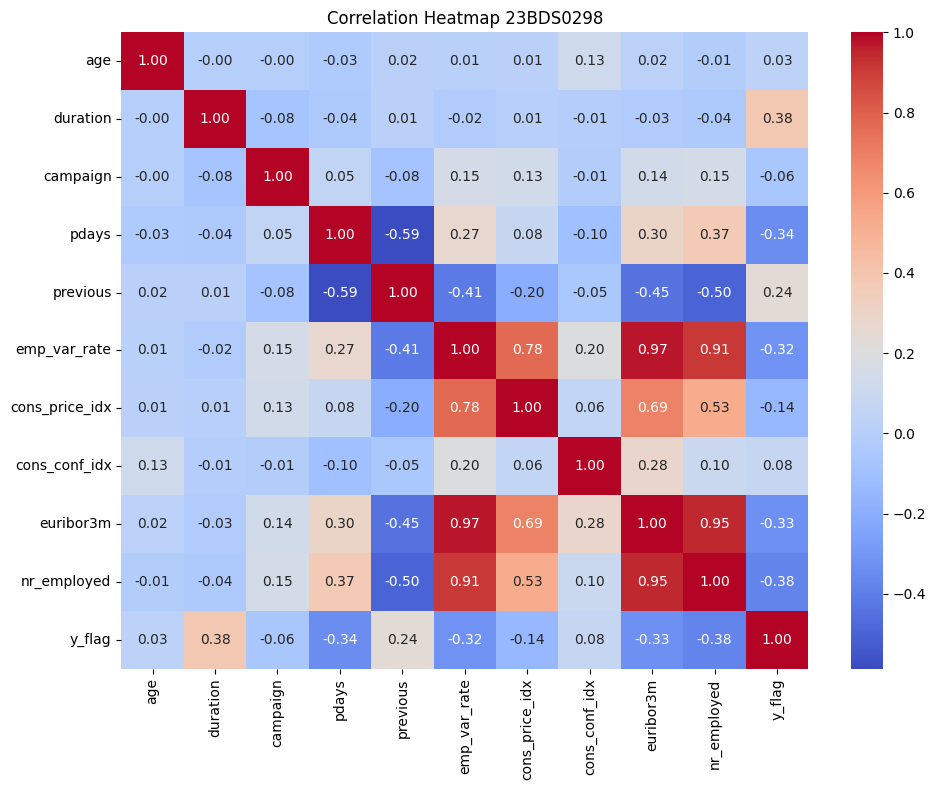

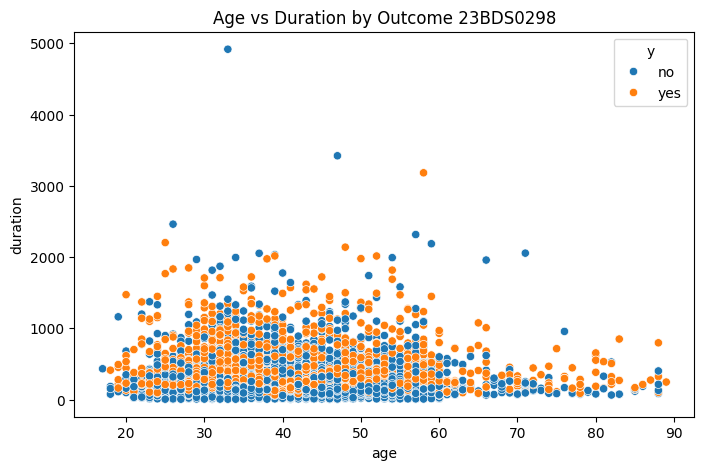

/tmp/ipykernel_2717/1117197950.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index="age_group", columns="marital", values="y_flag", aggfunc="mean")


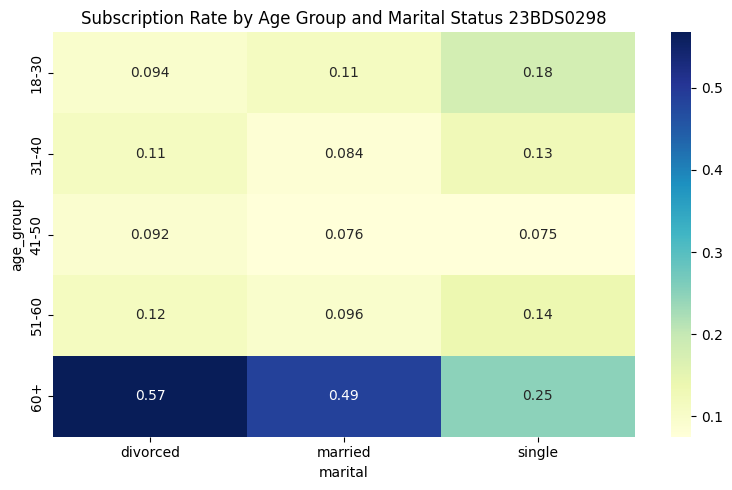

In [48]:
# 8. Multivariate analysis
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap 23BDS0298")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="duration", hue="y", data=df)
print("\n")
plt.title("Age vs Duration by Outcome 23BDS0298")
plt.show()

plt.figure(figsize=(8, 5))
pivot = df.pivot_table(index="age_group", columns="marital", values="y_flag", aggfunc="mean")
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
print("\n")
plt.title("Subscription Rate by Age Group and Marital Status 23BDS0298")
plt.tight_layout()
plt.show()

df.to_csv("bank_marketing_cleaned.csv", index=False)

In [49]:
# PHASE 2
# 9.1D Statistical Analysis
from scipy import stats

num_cols = ["age", "duration", "campaign", "pdays", "previous",
            "emp_var_rate", "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed"]

summary_1d = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "mode": df[num_cols].mode().iloc[0],
    "std": df[num_cols].std(),
    "variance": df[num_cols].var(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "range": df[num_cols].max() - df[num_cols].min(),
    "Q1": df[num_cols].quantile(0.25),
    "Q3": df[num_cols].quantile(0.75),
    "IQR": df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25),
    "skewness": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurt()
})
print(summary_1d.round(3))

                    mean    median      mode      std   variance       min  \
age               40.111    38.000    32.000   10.460    109.407    17.000   
duration         256.051   179.000    71.000  259.744  67467.114     4.000   
campaign           2.605     2.000     1.000    2.916      8.502     1.000   
pdays            962.220   999.000   999.000  187.556  35177.171     0.000   
previous           0.174     0.000     0.000    0.501      0.251     0.000   
emp_var_rate       0.070     1.100     1.400    1.574      2.479    -3.400   
cons_price_idx    93.578    93.444    93.994    0.582      0.339    92.201   
cons_conf_idx    -40.548   -41.800   -36.400    4.621     21.358   -50.800   
euribor3m          3.608     4.857     4.857    1.736      3.013     0.634   
nr_employed     5166.600  5191.000  5228.100   72.458   5250.159  4963.600   

                     max     range        Q1        Q3      IQR  skewness  \
age               89.000    72.000    32.000    47.000   15.000 


 job
               count  percent
job                          
admin.          2175    26.41
blue-collar     1866    22.66
technician      1347    16.36
services         763     9.27
management       633     7.69
retired          324     3.93
entrepreneur     284     3.45
self-employed    255     3.10
housemaid        222     2.70
unemployed       198     2.40
student          168     2.04

 marital
          count  percent
marital                 
married    5056    61.40
single     2248    27.30
divorced    931    11.31

 education
                     count  percent
education                          
university.degree     2804    34.05
high.school           1913    23.23
basic.9y              1216    14.77
professional.course   1030    12.51
basic.4y               817     9.92
basic.6y               453     5.50
illiterate               2     0.02

 contact
           count  percent
contact                  
cellular    5214    63.32
telephone   3021    36.68

 poutcome
        

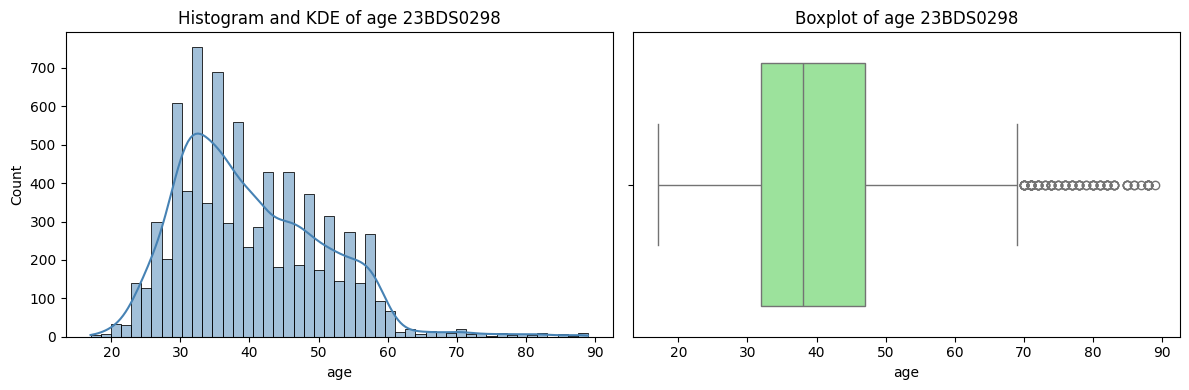

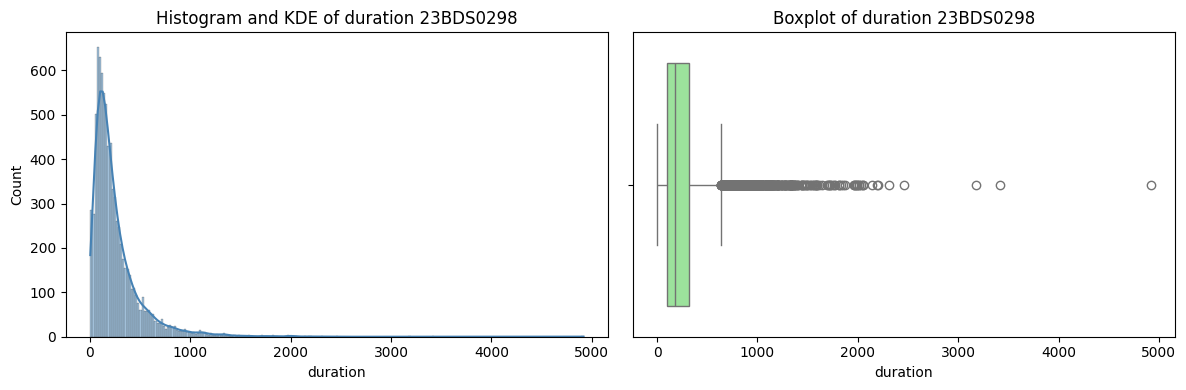

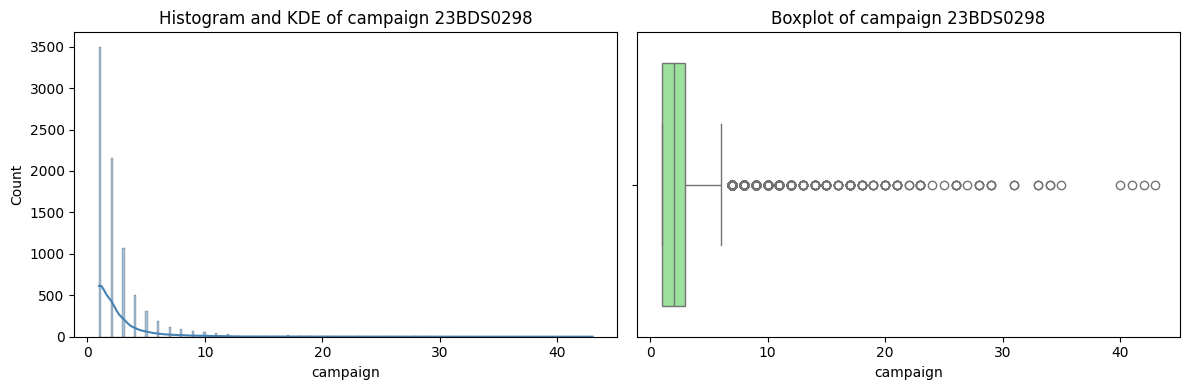

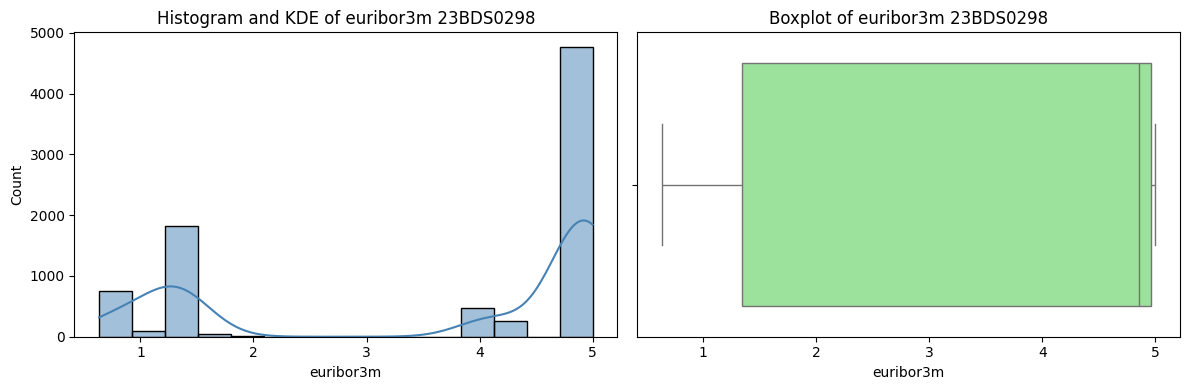

age: 92 outliers (1.12%)
duration: 559 outliers (6.79%)
campaign: 518 outliers (6.29%)

Shapiro-Wilk on age: stat=0.9619, p-value=4.352e-10
Not normally distributed


In [50]:
# Categorical: frequency and percentage
for col in ["job", "marital", "education", "contact", "poutcome", "y"]:
    freq = df[col].value_counts()
    print("\n", col)
    print(pd.DataFrame({"count": freq, "percent": (freq / len(df) * 100).round(2)}))

# Histogram + KDE, and boxplot
for col in ["age", "duration", "campaign", "euribor3m"]:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=ax[0], color="steelblue")
    ax[0].set_title(f"Histogram and KDE of {col} 23BDS0298")
    sns.boxplot(x=df[col], ax=ax[1], color="lightgreen")
    ax[1].set_title(f"Boxplot of {col} 23BDS0298")
    plt.tight_layout()
    plt.show()

# Outlier count using the IQR rule
for col in ["age", "duration", "campaign"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

# Normality test
sample = df["age"].sample(500, random_state=42)
stat, p = stats.shapiro(sample)
print(f"\nShapiro-Wilk on age: stat={stat:.4f}, p-value={p:.4g}")
print("Normal" if p > 0.05 else "Not normally distributed")

age vs duration: Pearson r=-0.001 (p=0.918), Spearman rho=-0.014 (p=0.192)
duration vs campaign: Pearson r=-0.076 (p=3.68e-12), Spearman rho=-0.086 (p=4.88e-15)
euribor3m vs nr_employed: Pearson r=0.945 (p=0), Spearman rho=0.930 (p=0)
emp_var_rate vs euribor3m: Pearson r=0.972 (p=0), Spearman rho=0.941 (p=0)


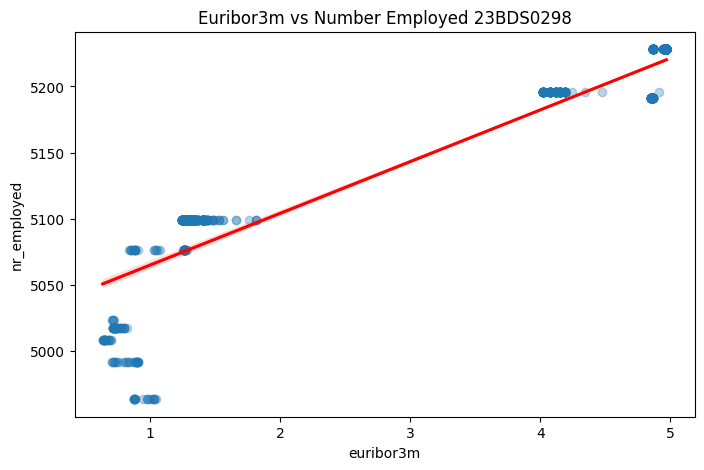

In [51]:
# 10. 2D Statistical Analysis
from scipy.stats import pearsonr, spearmanr, chi2_contingency, ttest_ind, f_oneway

# 10a. Numeric vs Numeric: Pearson and Spearman correlation
pairs = [("age", "duration"), ("duration", "campaign"),
         ("euribor3m", "nr_employed"), ("emp_var_rate", "euribor3m")]
for a, b in pairs:
    pr, pp = pearsonr(df[a], df[b])
    sr, sp = spearmanr(df[a], df[b])
    print(f"{a} vs {b}: Pearson r={pr:.3f} (p={pp:.3g}), Spearman rho={sr:.3f} (p={sp:.3g})")

plt.figure(figsize=(8, 5))
sns.regplot(x="euribor3m", y="nr_employed", data=df.sample(1500, random_state=42),
            scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.title("Euribor3m vs Number Employed 23BDS0298")
plt.show()

job vs y: chi2=272.59, dof=10, p=9.52e-53, Cramer's V=0.182
marital vs y: chi2=34.34, dof=2, p=3.49e-08, Cramer's V=0.065
education vs y: chi2=55.03, dof=6, p=4.57e-10, Cramer's V=0.082
poutcome vs y: chi2=889.34, dof=1, p=2.04e-195, Cramer's V=0.329


<Figure size 900x500 with 0 Axes>

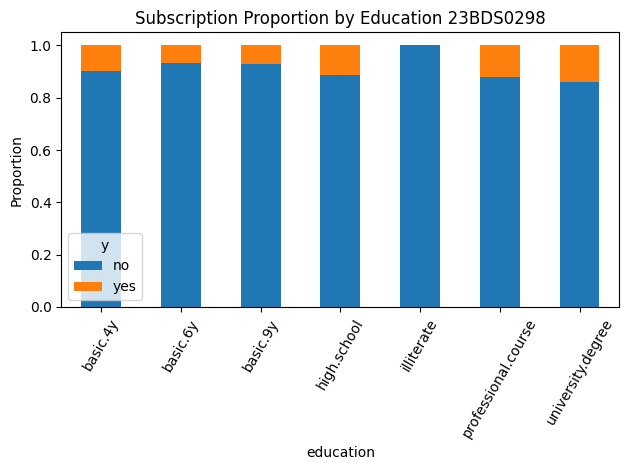

In [52]:
# 10b. Categorical vs Categorical: Chi-square test of independence
for col in ["job", "marital", "education", "poutcome"]:
    ct = pd.crosstab(df[col], df["y"])
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f"{col} vs y: chi2={chi2:.2f}, dof={dof}, p={p:.3g}, Cramer's V={cramers_v:.3f}")

plt.figure(figsize=(9, 5))
pd.crosstab(df["education"], df["y"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Subscription Proportion by Education 23BDS0298")
plt.ylabel("Proportion")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


Welch t-test on duration (yes vs no): t=24.39, p=1.74e-103
ANOVA on age across marital status: F=806.15, p=1.87e-320


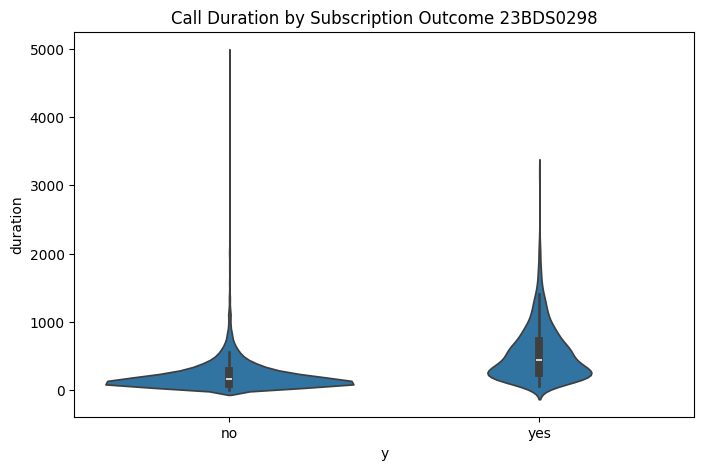

In [53]:
# 10c. Numeric vs Categorical: t-test and one-way ANOVA
yes = df[df["y"] == "yes"]["duration"]
no = df[df["y"] == "no"]["duration"]
t, p = ttest_ind(yes, no, equal_var=False)
print(f"\nWelch t-test on duration (yes vs no): t={t:.2f}, p={p:.3g}")

groups = [g["age"].values for _, g in df.groupby("marital")]
f, p = f_oneway(*groups)
print(f"ANOVA on age across marital status: F={f:.2f}, p={p:.3g}")

plt.figure(figsize=(8, 5))
sns.violinplot(x="y", y="duration", data=df)
plt.title("Call Duration by Subscription Outcome 23BDS0298")
plt.show()

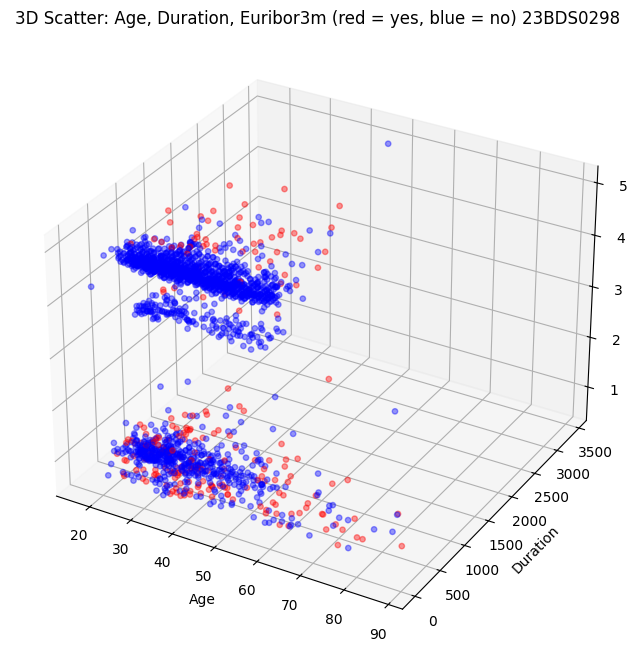

In [54]:
# 11. 3D Statistical Analysis
from mpl_toolkits.mplot3d import Axes3D

# 11a. 3D scatter plot: three numeric variables coloured by outcome
sample3d = df.sample(2000, random_state=42)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
colors = sample3d["y"].map({"yes": "red", "no": "blue"})
ax.scatter(sample3d["age"], sample3d["duration"], sample3d["euribor3m"],
           c=colors, alpha=0.4, s=15)
ax.set_xlabel("Age")
ax.set_ylabel("Duration")
ax.set_zlabel("Euribor3m")
ax.set_title("3D Scatter: Age, Duration, Euribor3m (red = yes, blue = no) 23BDS0298")
plt.show()

contact   cellular                telephone               
marital   divorced married single  divorced married single
age_group                                                 
18-30        0.147   0.163  0.225     0.000   0.028  0.063
31-40        0.135   0.114  0.157     0.073   0.041  0.059
41-50        0.131   0.103  0.096     0.033   0.037  0.035
51-60        0.139   0.120  0.170     0.081   0.055  0.091
60+          0.594   0.491  0.286     0.400   0.444  0.000


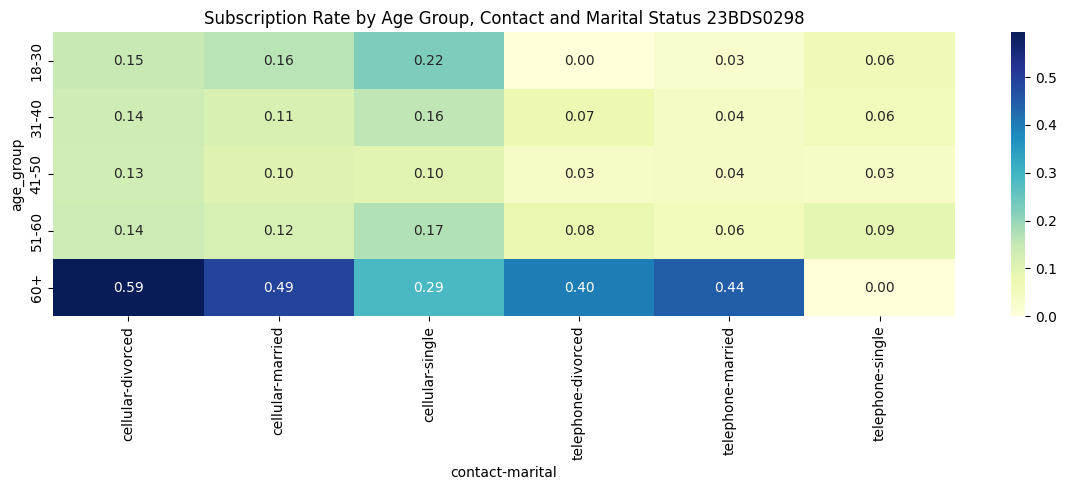

In [55]:
# 11b. Three-way pivot: subscription rate by age group, marital status and contact type
three_way = df.pivot_table(index="age_group", columns=["contact", "marital"],
                           values="y_flag", aggfunc="mean", observed=True)
print(three_way.round(3))

plt.figure(figsize=(12, 5))
sns.heatmap(three_way, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Subscription Rate by Age Group, Contact and Marital Status 23BDS0298")
plt.tight_layout()
plt.show()


Correlation age-duration: -0.0011
Partial correlation age-duration | euribor3m: -0.0005
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        283.7396     12.792     22.182      0.000     258.665     308.814
age           -0.0206      0.273     -0.076      0.940      -0.556       0.514
campaign      -6.5933      0.988     -6.672      0.000      -8.530      -4.656
euribor3m     -2.6839      1.660     -1.616      0.106      -5.939       0.571
R-squared: 0.0062


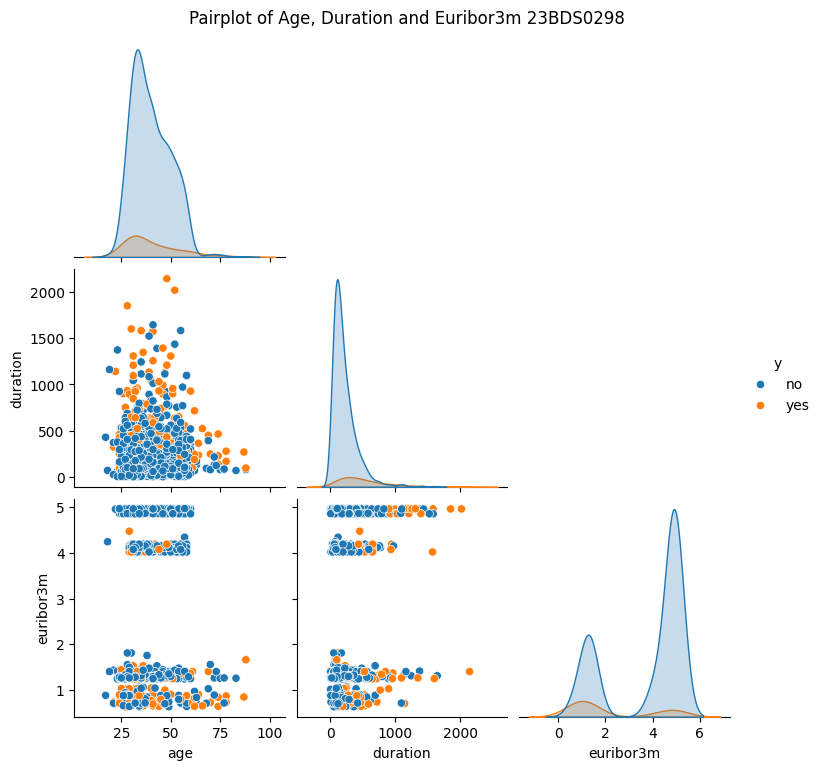

In [56]:
# 11c. Partial correlation of age and duration controlling for euribor3m
def partial_corr(data, x, y, z):
    rx = data[x] - np.polyval(np.polyfit(data[z], data[x], 1), data[z])
    ry = data[y] - np.polyval(np.polyfit(data[z], data[y], 1), data[z])
    return np.corrcoef(rx, ry)[0, 1]

print("\nCorrelation age-duration:", round(df["age"].corr(df["duration"]), 4))
print("Partial correlation age-duration | euribor3m:",
      round(partial_corr(df, "age", "duration", "euribor3m"), 4))

# 11d. Multiple linear regression
import statsmodels.api as sm
X = sm.add_constant(df[["age", "campaign", "euribor3m"]])
model = sm.OLS(df["duration"], X).fit()
print(model.summary().tables[1])
print("R-squared:", round(model.rsquared, 4))

# 11e. Pairplot of three numeric variables by outcome
sns.pairplot(df.sample(1500, random_state=42),
             vars=["age", "duration", "euribor3m"], hue="y", corner=True)
plt.suptitle("Pairplot of Age, Duration and Euribor3m 23BDS0298", y=1.02)
plt.show()

In [57]:
# 12. Time series check
print("Columns with date information:", [c for c in df.columns if c in ("month", "day_of_week")])

Columns with date information: ['month', 'day_of_week']


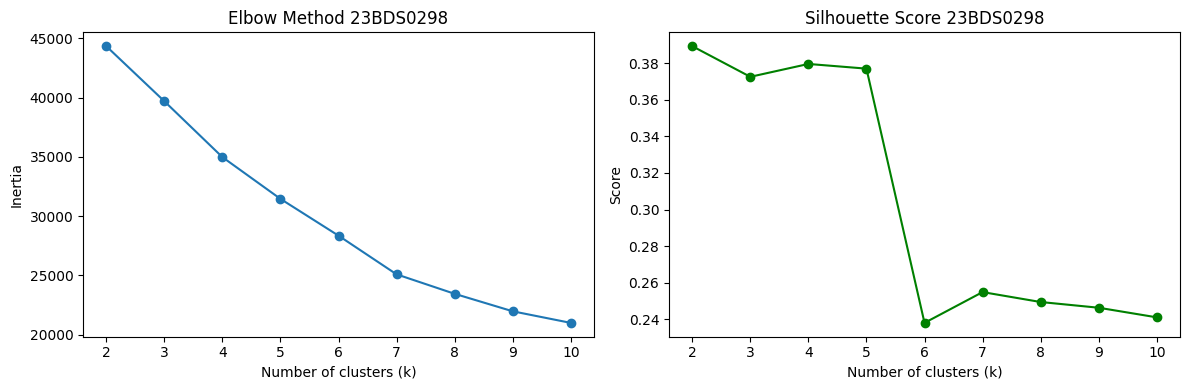

Best k by silhouette score: 2
kmeans_cluster
0    5362
1    2873
Name: count, dtype: int64
                  age  duration  campaign  previous  emp_var_rate  \
kmeans_cluster                                                      
0               40.35    251.87      2.88       0.0          1.15   
1               39.66    263.86      2.08       0.5         -1.94   

                cons_price_idx  cons_conf_idx  euribor3m  y_flag  
kmeans_cluster                                                    
0                        93.87         -39.42       4.83    0.04  
1                        93.04         -42.65       1.32    0.24  


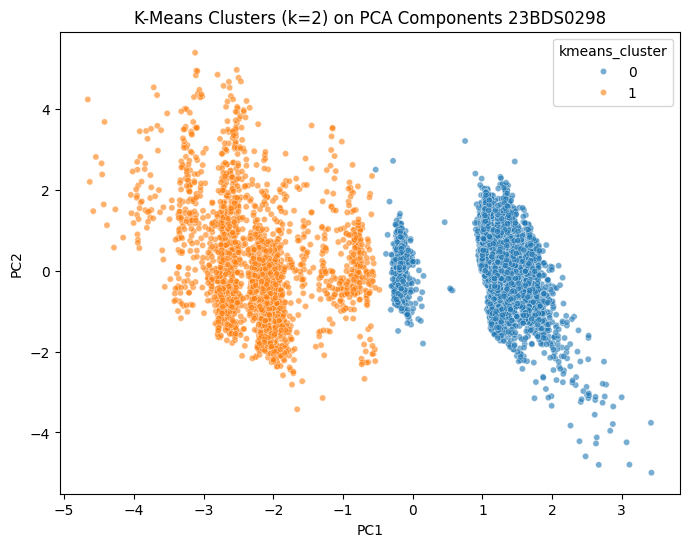

In [58]:
# 13. K-Means Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_cols = ["age", "duration", "campaign", "previous",
                "emp_var_rate", "cons_price_idx", "cons_conf_idx", "euribor3m"]
X_scaled = StandardScaler().fit_transform(df[cluster_cols])

# Elbow method and silhouette score for k = 2 to 10
inertias, sil_scores = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(k_range), inertias, marker="o")
ax[0].set_title("Elbow Method 23BDS0298")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")
ax[1].plot(list(k_range), sil_scores, marker="o", color="green")
ax[1].set_title("Silhouette Score 23BDS0298")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette score:", best_k)

kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)
print(df["kmeans_cluster"].value_counts().sort_index())

print(df.groupby("kmeans_cluster")[cluster_cols + ["y_flag"]].mean().round(2))

# Visualising clusters in 2D using PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["kmeans_cluster"],
                palette="tab10", alpha=0.6, s=20)
plt.title(f"K-Means Clusters (k={best_k}) on PCA Components 23BDS0298")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

ward: cophenetic correlation = 0.6448
complete: cophenetic correlation = 0.8132
average: cophenetic correlation = 0.8835
single: cophenetic correlation = 0.8164


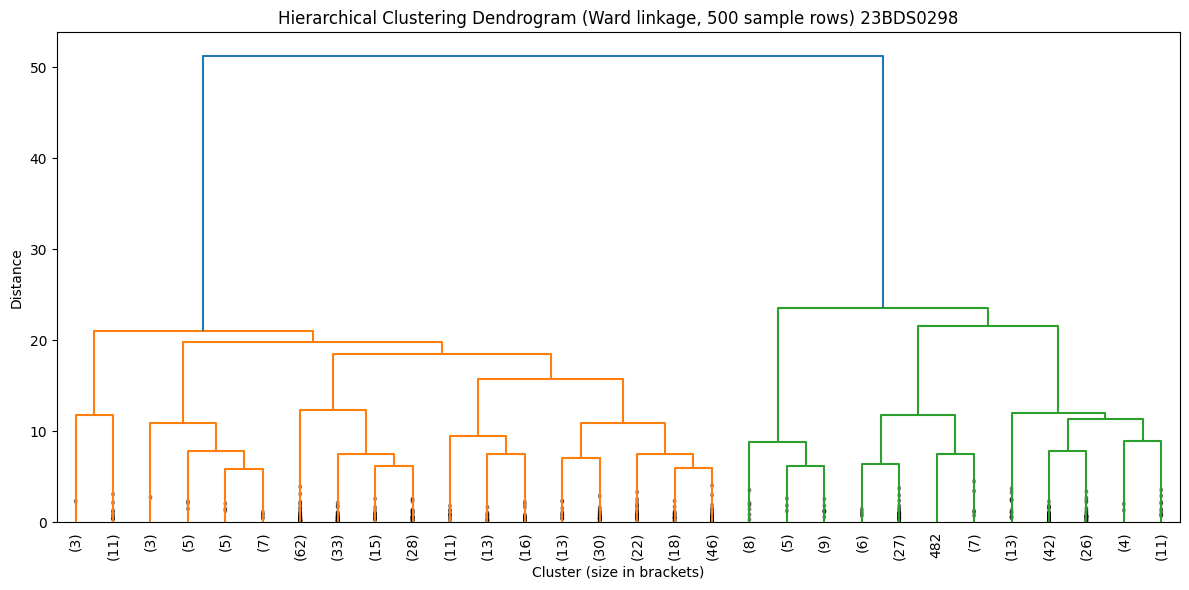

hc_cluster
1    341
2    159
Name: count, dtype: int64
Silhouette score (hierarchical): 0.3909
              age  duration  campaign  previous  emp_var_rate  cons_price_idx  \
hc_cluster                                                                      
1           41.06    242.07      2.81      0.03          1.10           93.84   
2           37.60    253.80      2.25      0.38         -2.02           93.01   

            cons_conf_idx  euribor3m  y_flag  
hc_cluster                                    
1                  -39.57        4.8    0.04  
2                  -43.25        1.2    0.21  


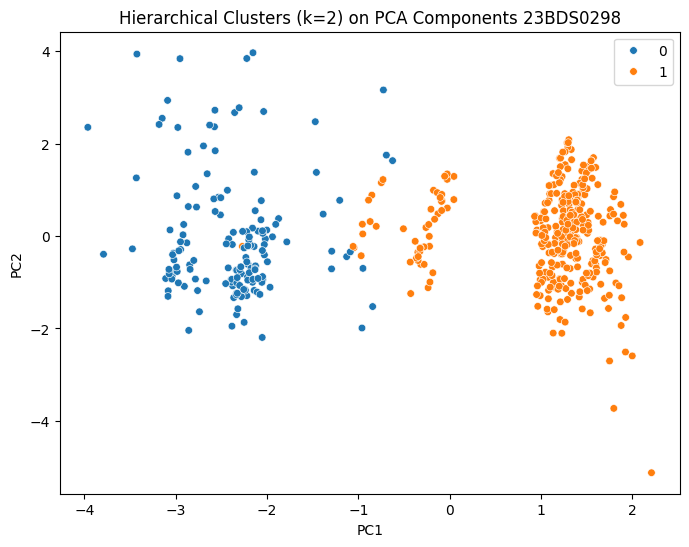

In [59]:
# 14. Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering

hc_sample = df.sample(500, random_state=42)
X_hc = StandardScaler().fit_transform(hc_sample[cluster_cols])

# Compare linkage methods using the cophenetic correlation
for method in ["ward", "complete", "average", "single"]:
    Z_tmp = linkage(X_hc, method=method)
    c, _ = cophenet(Z_tmp, pdist(X_hc))
    print(f"{method}: cophenetic correlation = {c:.4f}")

# Dendrogram using Ward linkage
Z = linkage(X_hc, method="ward")
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, 500 sample rows) 23BDS0298")
plt.xlabel("Cluster (size in brackets)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Cut the tree into clusters
hc_sample = hc_sample.copy()
hc_sample["hc_cluster"] = fcluster(Z, t=best_k, criterion="maxclust")
print(hc_sample["hc_cluster"].value_counts().sort_index())
print("Silhouette score (hierarchical):", round(silhouette_score(X_hc, hc_sample["hc_cluster"]), 4))
print(hc_sample.groupby("hc_cluster")[cluster_cols + ["y_flag"]].mean().round(2))

# Same result using sklearn, plotted on PCA components
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_hc)
coords_hc = PCA(n_components=2, random_state=42).fit_transform(X_hc)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords_hc[:, 0], y=coords_hc[:, 1], hue=agg_labels, palette="tab10", s=30)
plt.title(f"Hierarchical Clusters (k={best_k}) on PCA Components 23BDS0298")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()